In [1]:
########################
#CODE INFORMATION

In [ ]:
#Getting Data
# https://projectpythia.org/mrms-cookbook/notebooks/ch4-realtimedata/
# Authors:
# Ty Janoski
# City College of New York and NOAA/OAR National Severe Storms Laboratory
# Mya Sears
# NSF National Center for Atmospheric Research
# Bella Condo
# University at Albany (State University of New York)
# JD Heaton
# Metropolitan State University of Denver
# MaKenna Collins
# Jackson State University
# Maxwell Grover
# Argonne National Laboratory

In [ ]:
########################
#LIBRARIES

In [174]:
#system packages
import os, re

In [ ]:
#plotting pacakges
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from metpy.plots import ctables
import pandas as pd

In [ ]:
# Packages required to request and open data from AWS S3
import s3fs
import urllib
import tempfile
import gzip
import xarray as xr

# Packages required for data visualization
import datetime
from datetime import timezone
import numpy.ma as ma
from metpy.plots import ctables
import numpy as np
import holoviews as hv
import pandas as pd
import panel as pn
import hvplot.xarray 
import matplotlib.colors as mcls
from matplotlib.colors import Normalize

hv.extension("bokeh")
pn.extension()

In [7]:
########################
#DATA SETUP

In [3]:
# Initialize the S3 filesystem as anonymous
aws = s3fs.S3FileSystem(anon=True)

In [59]:
aws

In [4]:
# Example code to execute: first five items in the 'CONUS' directory of the MRMS bucket on S3
print(aws.ls(f'noaa-mrms-pds/CONUS/')[0:5])

['noaa-mrms-pds/CONUS/ANC_ConvectiveLikelihood_00.00', 'noaa-mrms-pds/CONUS/ANC_FinalForecast_00.00', 'noaa-mrms-pds/CONUS/BREF_1HR_MAX_00.50', 'noaa-mrms-pds/CONUS/BrightBandBottomHeight_00.00', 'noaa-mrms-pds/CONUS/BrightBandTopHeight_00.00']


In [76]:
# Define dropdown options -- region and product from the AWS structure
region_options = [
    "CONUS",
    "ALASKA",
    "CARIB",
    "GUAM",
    "HAWAII"
]

product_options = [
    "MergedReflectivityQC_01.00",
]

# Create dropdown widgets for user selection
region_choice = pn.widgets.Select(name='Region', options=region_options, width=325)
product_choice = pn.widgets.Select(name='MRMS product', options=product_options, width=325)

pn.Column(region_choice, product_choice)

Column
    [0] Select(name='Region', options=['CONUS', 'ALASKA', ...], value='CONUS', width=325)
    [1] Select(name='MRMS product', options=['MergedReflectivityQC_01....], value='MergedReflectivityQC_01.0..., width=325)

In [110]:
# Retrieve the user selection from 'Region' 
region = region_choice.value

# Retrieve the user selection from 'MRMS product'
product = product_choice.value

In [78]:
########################
#DATA RETRIEVAL

In [ ]:
def SubsetDataRegion(data, lat_range=(25, 35), lon_range=(-100, -90)):
    """
    Subset an xarray DataArray to a given lat/lon region.
    """
    # Convert longitudes to 0–360 range if dataset uses that convention
    if data.longitude.max() > 180:
        lon_min_target = 360 + lon_range[0] if lon_range[0] < 0 else lon_range[0]
        lon_max_target = 360 + lon_range[1] if lon_range[1] < 0 else lon_range[1]
    else:
        lon_min_target, lon_max_target = lon_range

    lat_min_target, lat_max_target = lat_range

    # Get nearest actual grid points
    lat_min = float(data.latitude.sel(latitude=lat_min_target, method='nearest'))
    lat_max = float(data.latitude.sel(latitude=lat_max_target, method='nearest'))
    lon_min = float(data.longitude.sel(longitude=lon_min_target, method='nearest'))
    lon_max = float(data.longitude.sel(longitude=lon_max_target, method='nearest'))

    # Apply slicing (note reversed latitude order if data is descending)
    subset = data.sel(latitude=slice(lat_max, lat_min),
                      longitude=slice(lon_min, lon_max))

    return subset

In [191]:
# ============================================================
# Helper: extract time from filename
# ============================================================
def extract_time_from_filename(fname):
    """Parse MRMS filename and return a pandas.Timestamp (UTC)."""
    match = re.search(r"_(\d{8}-\d{6})\.grib2\.gz", fname)
    return pd.to_datetime(match.group(1), format="%Y%m%d-%H%M%S", utc=True)

# ============================================================
# Select target times at 6-hour intervals
# ============================================================
def select_nearest_to_targets(files, interval_hours=6):
    """Return subset of file paths nearest to each N-hour UTC time."""
    # Extract actual timestamps from filenames
    file_times = pd.Series({f: extract_time_from_filename(f) for f in files}).sort_values()

    # Build list of desired UTC times covering file range
    start = file_times.min().floor(f"{interval_hours}h")   # lowercase h
    end   = file_times.max().ceil(f"{interval_hours}h")
    targets = pd.date_range(start, end, freq=f"{interval_hours}h", tz="UTC")

    selected = []
    for t in targets:
        nearest_idx = (abs(file_times - t)).argmin()
        selected.append(file_times.index[nearest_idx])

    return selected

# ============================================================
# Main Loop: Load multiple dates
# ============================================================
aws = s3fs.S3FileSystem(anon=True)
region = "CONUS"
product = "MergedReflectivityQC_01.00"

datestrings = ["20220630", "20220701", "20220702"]

all_datasets = []

for datestring in datestrings:
    print(f"\n=== Processing {datestring} ===")

    # List all files for this date
    try:
        data_files = aws.ls(f'noaa-mrms-pds/{region}/{product}/{datestring}/')
    except Exception as e:
        print(f"Could not access {datestring}: {e}")
        continue

    if not data_files:
        print(f"No files found for {datestring}")
        continue

    data_files = sorted(data_files)

    # (Optional) Filter to specific times or interval
    # selected_files = data_files[::6] #hourly
    # selected_files = data_files[::36] #6-hourly
    selected_files = select_nearest_to_targets(data_files, interval_hours=6)

    datasets = []
    for f in selected_files:
        print(f'working on {f}')
        try:
            response = urllib.request.urlopen(f"https://noaa-mrms-pds.s3.amazonaws.com/{f[14:]}")
            compressed_file = response.read()

            with tempfile.NamedTemporaryFile(suffix=".grib2") as tmp:
                tmp.write(gzip.decompress(compressed_file))
                tmp.flush()
                ds = xr.load_dataarray(tmp.name, engine="cfgrib", decode_timedelta=True)

                # Drop differing coords
                for coord in ["valid_time", "step"]:
                    if coord in ds.coords:
                        ds = ds.drop_vars(coord)

                # Attach true timestamp from filename
                file_time = extract_time_from_filename(f)
                ds = ds.expand_dims(time=[file_time])

                # Subset
                subset = SubsetDataRegion(ds, lat_range=(25, 35), lon_range=(-100, -90))
                datasets.append(subset)

        except Exception as e:
            print(f"Failed to load {f}: {e}")
            continue

    if datasets:
        day_data = xr.concat(datasets, dim="time", coords="minimal")
        all_datasets.append(day_data)

# ============================================================
# Combine all dates into one dataset
# ============================================================
if all_datasets:
    data_multi = xr.concat(all_datasets, dim="time", coords="minimal")
    print("\nCombined dataset shape:", data_multi.shape)
    print("Time coverage:", data_multi.time.values[0], "→", data_multi.time.values[-1])
else:
    print("No datasets loaded.")


=== Processing 20220630 ===
working on noaa-mrms-pds/CONUS/MergedReflectivityQC_01.00/20220630/MRMS_MergedReflectivityQC_01.00_20220630-000041.grib2.gz


ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(41) ignored
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(41) ignored


working on noaa-mrms-pds/CONUS/MergedReflectivityQC_01.00/20220630/MRMS_MergedReflectivityQC_01.00_20220630-060038.grib2.gz


ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(38) ignored
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(38) ignored


working on noaa-mrms-pds/CONUS/MergedReflectivityQC_01.00/20220630/MRMS_MergedReflectivityQC_01.00_20220630-120035.grib2.gz


...

working on noaa-mrms-pds/CONUS/MergedReflectivityQC_01.00/20220702/MRMS_MergedReflectivityQC_01.00_20220702-180039.grib2.gz


ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(39) ignored
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(39) ignored


working on noaa-mrms-pds/CONUS/MergedReflectivityQC_01.00/20220702/MRMS_MergedReflectivityQC_01.00_20220702-235841.grib2.gz


ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(41) ignored
ECCODES ERROR   :  Key dataTime (unpack_long): Truncating time: non-zero seconds(41) ignored



Combined dataset shape: (15, 1001, 1001)
Time coverage: 1656547241000000000 → 1656806321000000000


In [200]:
#saving
times = pd.to_datetime(data_multi.time.to_pandas()).tz_localize(None)
data_multi = data_multi.assign_coords(time=times)

# Now you can save safely
outputFile = "MRMS_Reflectivity_TRACERregion_20220630-0701.nc"
data_multi.to_netcdf(outputFile)


<xarray.DataArray 'unknown' (time: 15, latitude: 1001, longitude: 1001)> Size: 60MB
array([[[-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        ...,
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.]],

       [[-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        ...,
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.]],

       [[-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        ...,
...
        ...,
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.]],

       [[-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        ...,
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.]],

       [[-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        [-999., -999., -999., ...,  -99.,  -99.,  -99.],
        ...,
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.],
        [-999., -999., -999., ..., -999., -999., -999.]]], dtype=float32)
Coordinates:
  * time            (time) datetime64[ns, UTC] 120B 2022-06-30 00:00:41+00:00...
  * latitude        (latitude) float64 8kB 35.0 34.99 34.98 ... 25.02 25.01 25.0
  * longitude       (longitude) float64 8kB 260.0 260.0 260.0 ... 270.0 270.0
    heightAboveSea  float64 8B 1e+03
Attributes: (12/30)
    GRIB_paramId:                             0
    GRIB_dataType:                            ra
    GRIB_numberOfPoints:                      24500000
    GRIB_typeOfLevel:                         heightAboveSea
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                unknown
    GRIB_shortName:                           unknown
    GRIB_units:                               unknown
    long_name:                                unknown
    units:                                    unknown
    standard_name:                            unknown

In [207]:
inputFile = "MRMS_Reflectivity_TRACERregion_20220630-0701.nc"
data_multi = xr.load_dataset(inputFile)

In [205]:
#########################################
#PLOTTING FUNCTIONS

In [260]:
# ============================================================
# Preload static map features (to avoid repeated downloads)
# ============================================================
COASTLINE = cfeature.COASTLINE.with_scale("50m")
STATES = cfeature.STATES.with_scale("50m")
BORDERS = cfeature.BORDERS.with_scale("50m")

# ============================================================
# Function: Plot MRMS reflectivity on a provided axis
# ============================================================
def PlotMRMSReflectivity(axis, data,
                         title_prefix="MRMS Reflectivity",
                         cmap_name="NWSReflectivity",
                         data_crs=ccrs.PlateCarree()):
    """
    Plot MRMS reflectivity (or similar data) on an existing Cartopy axis.

    Parameters
    ----------
    axis : cartopy.mpl.geoaxes.GeoAxesSubplot
        Axis to draw the map on (must be created with a Cartopy projection).
    data : xarray.DataArray
        MRMS reflectivity field with .latitude, .longitude, .time coords.
    title_prefix : str, optional
        Title text prefix (default: 'MRMS Reflectivity').
    cmap_name : str, optional
        Colormap name from MetPy ctables.
    data_crs : cartopy.crs projection, optional
        CRS of the data grid (usually PlateCarree for MRMS).
    """

    # --- Mask and extract ---
    data = data.where(data > 0, np.nan)
    lons = data.longitude
    lats = data.latitude
    values = data.values
    time_str = pd.to_datetime(data.time.values).strftime("%Y-%m-%d %H:%M UTC")

    # --- Domain bounds ---
    minLon, maxLon = float(lons.min()), float(lons.max())
    minLat, maxLat = float(lats.min()), float(lats.max())

    # --- Set map extent ---
    axis.set_extent([minLon, maxLon, minLat, maxLat], crs=data_crs)

    # --- Colormap ---
    ref_norm, ref_cmap = ctables.registry.get_with_steps(cmap_name, 5, 5)

    # --- Map features ---
    axis.add_feature(COASTLINE, linewidth=0.5)
    axis.add_feature(STATES, linewidth=0.5)
    axis.add_feature(BORDERS, linewidth=0.7)

    # --- Plot data ---
    mesh = axis.pcolormesh(
        lons, lats, values,
        transform=data_crs,
        cmap=ref_cmap, norm=ref_norm,
        shading="auto"
    )

    # --- Title ---
    axis.set_title(f"{title_prefix}\n{time_str}", fontsize=9, loc="left")

    # --- Tighten subplot area (no internal padding) ---
    axis.margins(0)
    axis.set_aspect("auto", adjustable="box")
    axis.set_anchor("C")

    return mesh  # return the QuadMesh for colorbar handling

In [261]:
#########################################
#PLOTTING

Text(0.5, 0.99, 'MRMS Merged Reflectivity – TRACER Region')

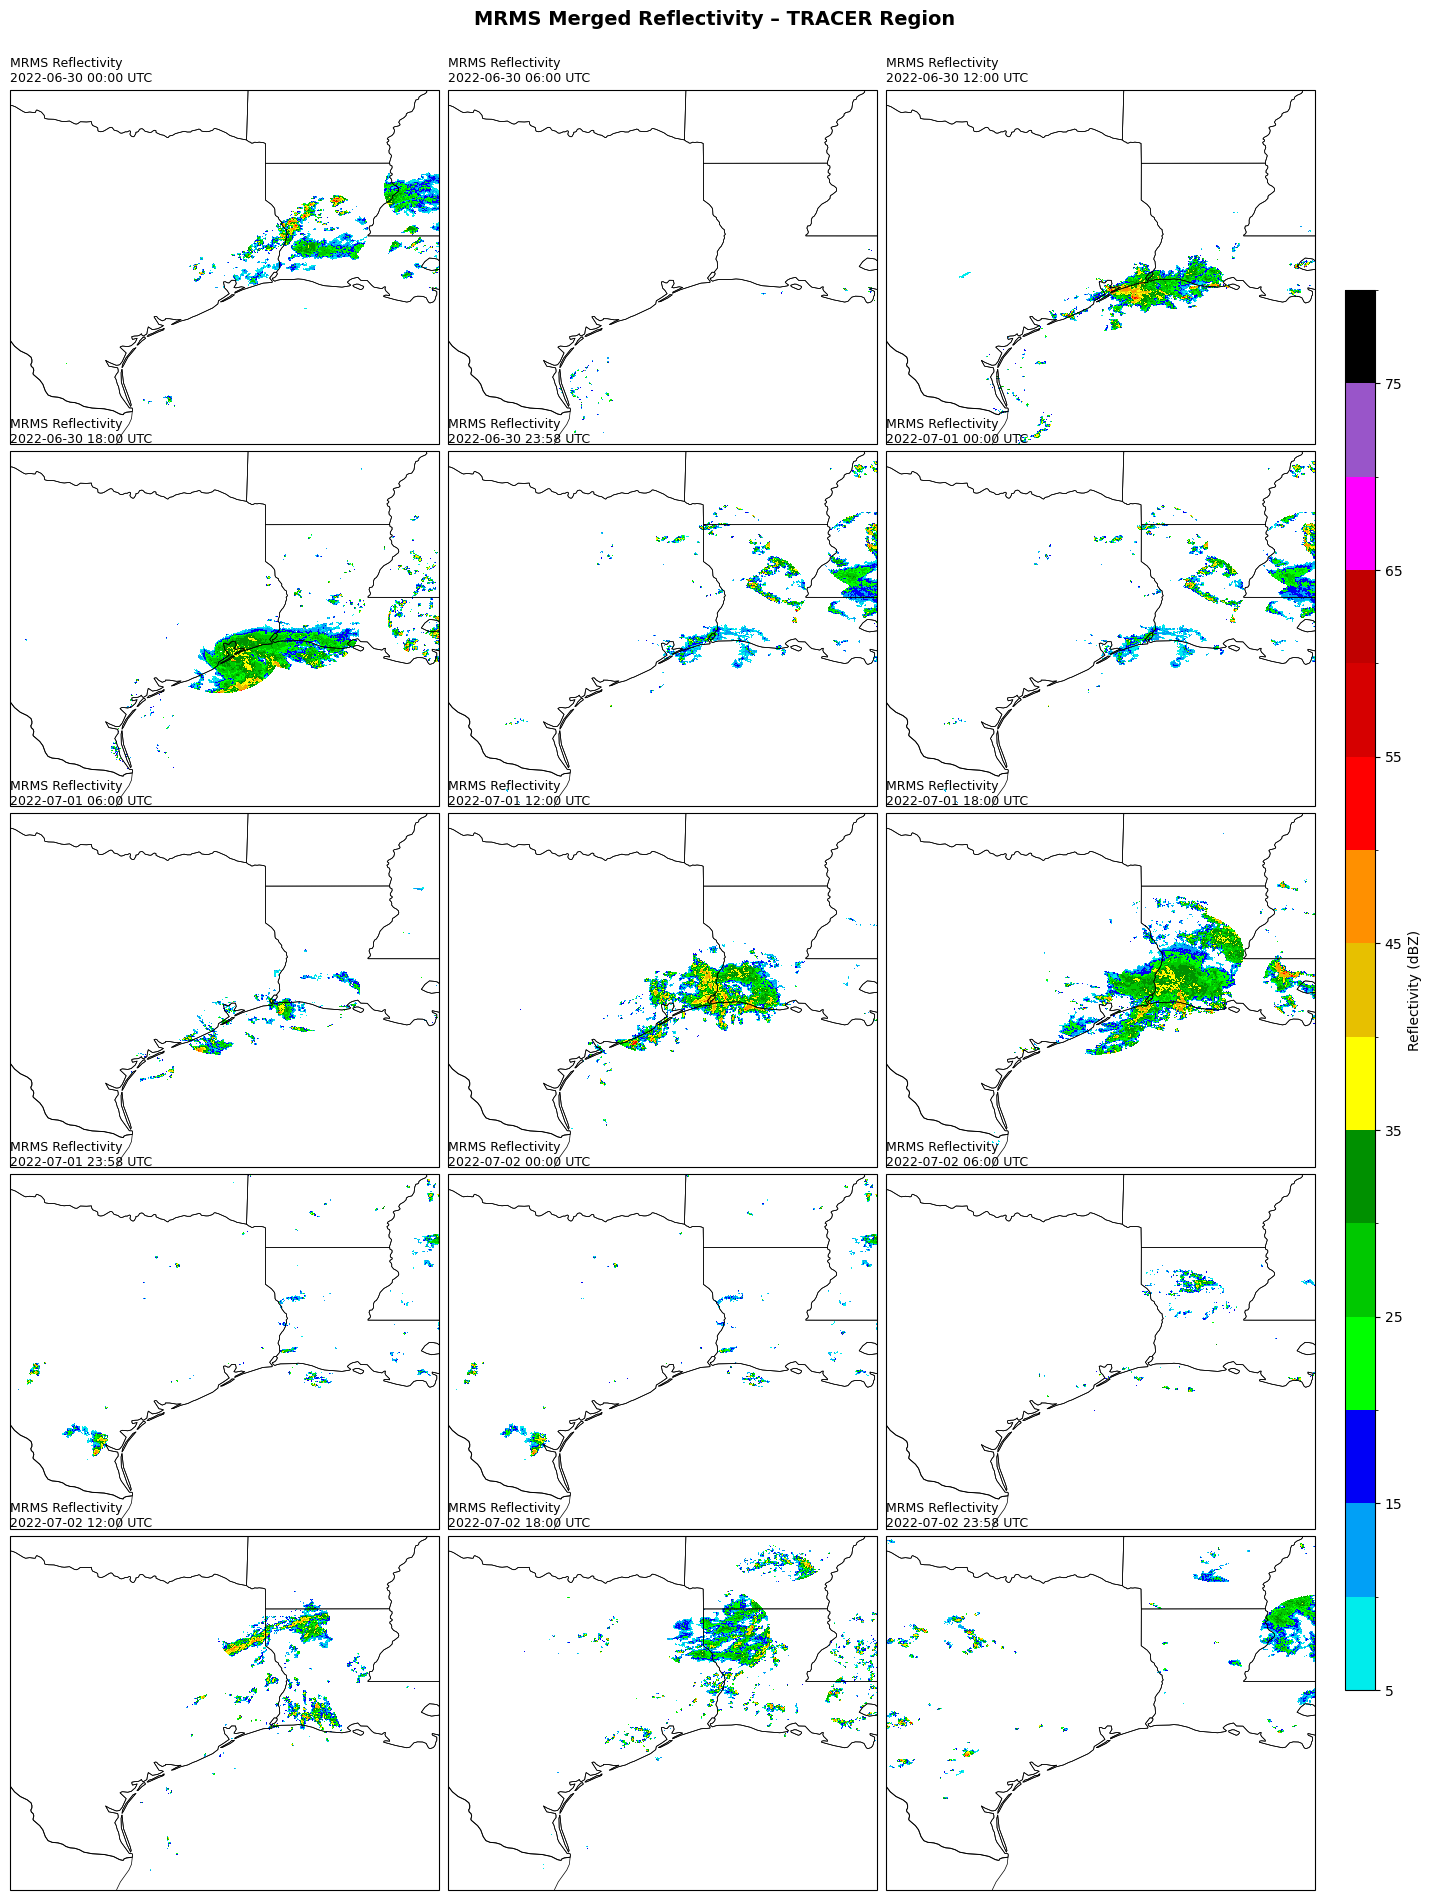

In [262]:
Ntime = data_multi.sizes["time"]
ncols = 3
nrows = int(np.ceil(Ntime / ncols))


fig = plt.figure(figsize=(5 * ncols, 4 * nrows))
gs = gridspec.GridSpec(nrows, ncols,
                       left=0.03, right=0.90, bottom=0.05, top=0.95,
                       wspace=0.02, hspace=0.02)

axes = []
for t in range(Ntime):
    row, col = divmod(t, ncols)
    ax = fig.add_subplot(gs[row, col], projection=ccrs.Mercator())
    data_t = data_multi.isel(time=t)['unknown']
    mesh = PlotMRMSReflectivity(ax, data_t)
    axes.append(ax)

# Hide unused panels
for ax in axes[Ntime:]:
    ax.set_visible(False)

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Reflectivity (dBZ)")

fig.suptitle("MRMS Merged Reflectivity – TRACER Region",
             fontsize=14, fontweight="bold", y=0.99)
